# Сравнение распределений до конкатенации и после

Три варианта представления текстов на основе эмбеддингов:
1. Mean pooling — усреднение эмбеддингов предложений.
2. Mean diff pooling — усреднение разностей эмбеддингов соседних предложений.
3. Конкатенация первого и второго.

Для каждого из представлений была проведена визуализация распределений с использованием методов понижения размерности:
- PCA
- t-SNE

### Энкодеры

1. all-mpnet-base-v2

In [1]:
ENCODERS = [
    "all-mpnet-base-v2",
]

DEVICE = "mps"

CACHE_DIR = "../emb_cache"

In [2]:
import numpy as np
from sklearn.metrics import silhouette_score, davies_bouldin_score
import torch
import pandas as pd
from sentence_transformers import SentenceTransformer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.model_selection import train_test_split
import re
import random
import hashlib
from tqdm import tqdm
import torch.nn.functional as F

import nltk
nltk.download('punkt')

[nltk_data] Downloading package punkt to /Users/artfultom/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [4]:
import os
from dotenv import load_dotenv

load_dotenv()
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Загрузка датасетов

In [5]:
filenames = [
    "../datasets/mistral_essays_1.csv",
    "../datasets/mistral_essays_2.csv",
    "../datasets/mistral_essays_3.csv",
    "../datasets/mistral_essays_4.csv",
    "../datasets/mistral_essays_5.csv",
    "../datasets/llama_essays_1.csv",
    "../datasets/llama_essays_2.csv",
    "../datasets/llama_essays_3.csv",
    "../datasets/llama_essays_4.csv",
    "../datasets/llama_essays_5.csv",
    "../datasets/deepseek_essays_1.csv",
    "../datasets/deepseek_essays_2.csv",
    "../datasets/deepseek_essays_3.csv",
    "../datasets/deepseek_essays_4.csv",
    "../datasets/deepseek_essays_5.csv",
    "../datasets/chatgpt_essays_1.csv",
    "../datasets/chatgpt_essays_2.csv",
    "../datasets/chatgpt_essays_3.csv",
    "../datasets/chatgpt_essays_4.csv",
    "../datasets/chatgpt_essays_5.csv",
]
df_ai = pd.concat([pd.read_csv(f) for f in filenames], ignore_index=True).assign(label=1)[["text", "label"]]

df_human = pd.read_csv("../datasets/ivy_panda_essays.csv").assign(label=0)[["text", "label"]].reset_index(drop=True)
_, df_human_test = train_test_split(df_human, test_size=len(df_ai), random_state=SEED)

df_all = pd.concat([df_ai, df_human_test], ignore_index=True).sample(frac=1, random_state=SEED)

In [6]:
print(f"Загружено {len(df_all)} записей (синтетика + живые, test)")

Загружено 74976 записей (синтетика + живые, test)


In [7]:
def print_big_header(text, width=100):
    print("\n" + "=" * width)
    print(text.center(width))
    print("=" * width)

In [8]:
FIGSIZE = (8, 4)
PALETTE = {0: "blue", 1: "orange"}
POINT_SIZE = 20
ALPHA = 0.6

def plot_pca_projection(X, y, title):
    X_2d = PCA(n_components=2, random_state=SEED).fit_transform(X)

    plt.figure(figsize=FIGSIZE)
    scatter = sns.scatterplot(
        x=X_2d[:, 0],
        y=X_2d[:, 1],
        hue=y,
        palette=PALETTE,
        alpha=ALPHA,
        s=POINT_SIZE
    )

    plt.title(title)

    handles, _ = scatter.get_legend_handles_labels()
    plt.legend(handles=handles, labels=["Человек", "ИИ"])

    plt.tight_layout()
    plt.show()

def plot_tsne(X, y, title):
    idx = np.random.choice(len(X), size=min(2000, len(X)), replace=False)
    Xsub = X[idx]
    ysub = y[idx]
    
    Xp = PCA(30, random_state=SEED).fit_transform(Xsub)
    Xt = TSNE(n_components=2, perplexity=30, random_state=SEED).fit_transform(Xp)
    
    plt.figure(figsize=FIGSIZE)

    scatter = sns.scatterplot(
        x=Xt[:, 0],
        y=Xt[:, 1],
        hue=ysub,
        palette=PALETTE,
        alpha=ALPHA,
        s=POINT_SIZE
    )

    plt.title(title)

    handles, _ = scatter.get_legend_handles_labels()
    plt.legend(handles=handles, labels=["Человек", "ИИ"])

    plt.tight_layout()
    plt.show()

In [9]:
def print_cluster_scores(X, y, title):
    print(title)
    print("Silhouette:", silhouette_score(X, y))
    print("Davies-Bouldin:", davies_bouldin_score(X, y))

In [10]:
def normalize_f(data):
    data = torch.from_numpy(data).float()
    data = F.normalize(data, p=2, dim=0)
    return data.numpy()

def _compute_hash(data, model_name):
    h = hashlib.sha256()
    h.update(model_name.encode("utf-8"))

    for text in data:
        h.update(text.encode("utf-8"))

    return h.hexdigest()[:32]

def get_embeddings(model, data, model_name, cache_dir=CACHE_DIR):
    safe_model_name = model_name.replace("/", "__")
    
    os.makedirs(cache_dir, exist_ok=True)

    cache_key = _compute_hash(data, model_name)
    cache_path = os.path.join(cache_dir, f"{safe_model_name}_{cache_key}.npy")
    cache_counts_path = os.path.join(cache_dir, f"{safe_model_name}_counts_{cache_key}.npy")

    if os.path.exists(cache_path) and os.path.exists(cache_counts_path):
        print(f"Loading embeddings from cache for {model_name}...")
        all_embeddings = np.load(cache_path)
        sentence_counts = np.load(cache_counts_path)
    else:
        print(f"Computing embeddings for {model_name}...")
    
        all_sentences = []
        sentence_counts = []
        for text in tqdm(data):
            text = re.sub(r"\n+", ". ", text)
            sentences = nltk.sent_tokenize(text)
    
            if "e5" in model_name:
                sentences = [f"passage: {s}" for s in sentences]
    
            all_sentences.extend(sentences)
            sentence_counts.append(len(sentences))
    
        all_embeddings = model.encode(
            all_sentences,
            batch_size=ENCODE_BATCH_SIZE,
            normalize_embeddings=True,
            show_progress_bar=True,
            device=DEVICE,
        )

        np.save(cache_path, all_embeddings)
        np.save(cache_counts_path, sentence_counts)

    mean_vals = []
    mean_diff_vals = []
    
    idx = 0
    for count in tqdm(sentence_counts):
        embeddings = all_embeddings[idx: idx + count]
        mean_vals.append(np.mean(embeddings, axis=0))
        
        diffs = embeddings[1:] - embeddings[:-1]
        mean_diff_val = np.mean(diffs, axis=0)
        mean_diff_val = normalize_f(mean_diff_val)
        mean_diff_vals.append(mean_diff_val)
        
        idx += count

    result = (
        np.array(mean_vals, dtype=np.float32), 
        np.array(mean_diff_vals, dtype=np.float32),
    )

    return result

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

MPNetModel LOAD REPORT from: sentence-transformers/all-mpnet-base-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading embeddings from cache for all-mpnet-base-v2...


100%|██████████████████████████████████████| 74976/74976 [00:02<00:00, 28143.09it/s]



                       МОДЕЛЬ: all-mpnet-base-v2. Распределение mean pooling                        
X_mean_test: (74976, 768)
y_test: (74976,) | аномалий: 37488


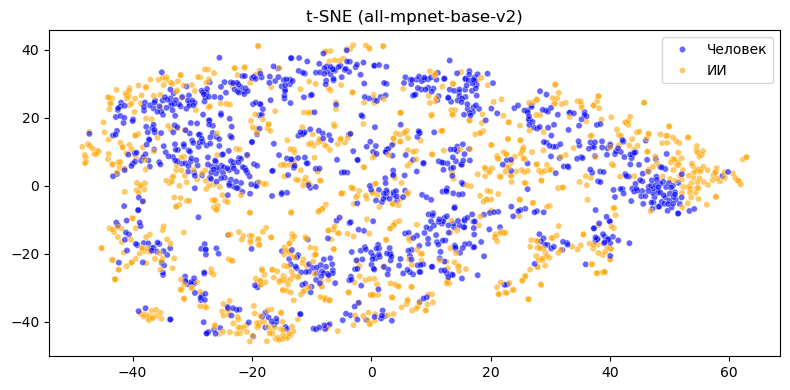

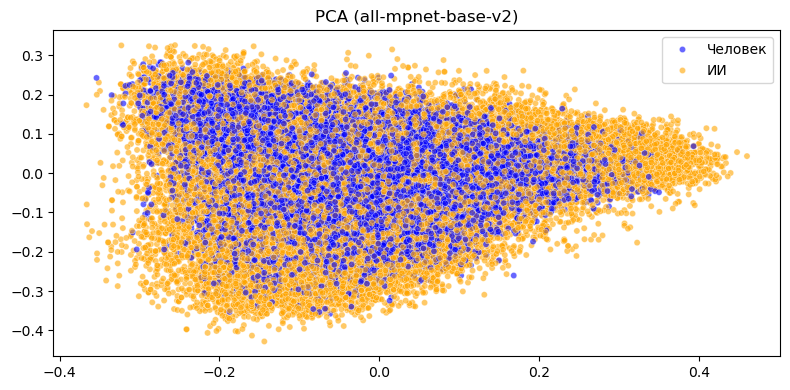

Кластерные метрики (all-mpnet-base-v2):
Silhouette: 0.024894345551729202
Davies-Bouldin: 8.15036299455037

                     МОДЕЛЬ: all-mpnet-base-v2. Распределение mean diff pooling                     
X_mean_diff_test: (74976, 768)
y_test: (74976,) | аномалий: 37488


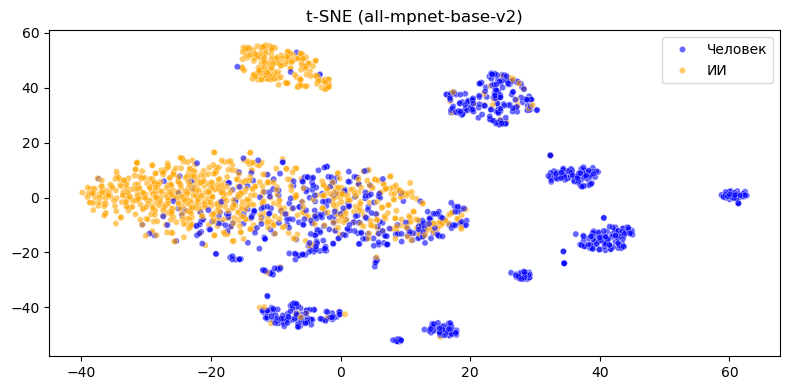

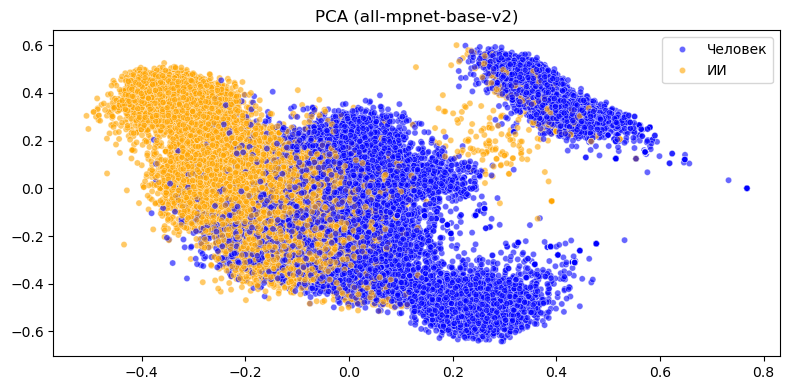

Кластерные метрики (all-mpnet-base-v2):
Silhouette: 0.046446382999420166
Davies-Bouldin: 4.802647418627557

          МОДЕЛЬ: all-mpnet-base-v2. Распределение concat(mean pooling, mean diff pooling)          
concat_test: (74976, 1536)
y_test: (74976,) | аномалий: 37488


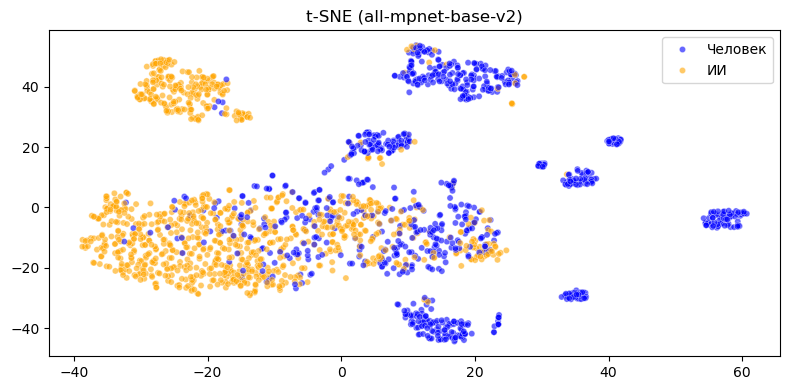

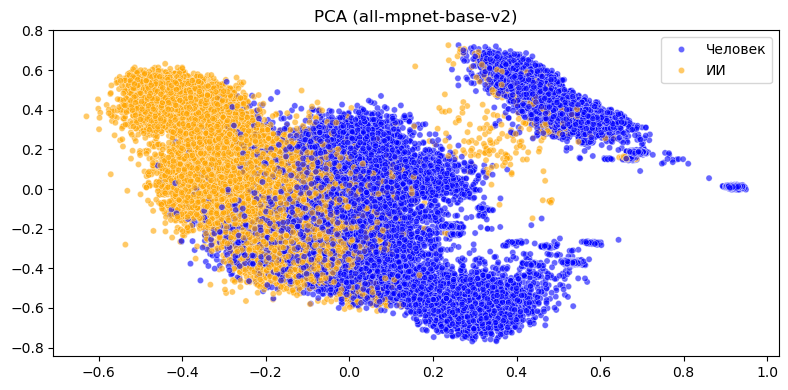

Кластерные метрики (all-mpnet-base-v2):
Silhouette: 0.04100454971194267
Davies-Bouldin: 5.082816684308302


In [11]:
for model_name in ENCODERS:
    model = SentenceTransformer(model_name)

    X_mean_test, X_mean_diff_test = get_embeddings(model, df_all['text'].tolist(), model_name)
    y_test = df_all['label'].values.astype(int)

    print_big_header(f"МОДЕЛЬ: {model_name}. Распределение mean pooling")
    
    print("X_mean_test:", X_mean_test.shape)
    print("y_test:", y_test.shape, "| аномалий:", sum(y_test))

    plot_tsne(X_mean_test, y_test, f"t-SNE ({model_name})")
    plot_pca_projection(X_mean_test, y_test, f"PCA ({model_name})")

    print_cluster_scores(X_mean_test, y_test, f"Кластерные метрики ({model_name}):")

    print_big_header(f"МОДЕЛЬ: {model_name}. Распределение mean diff pooling")
    
    print("X_mean_diff_test:", X_mean_diff_test.shape)
    print("y_test:", y_test.shape, "| аномалий:", sum(y_test))

    plot_tsne(X_mean_diff_test, y_test, f"t-SNE ({model_name})")
    plot_pca_projection(X_mean_diff_test, y_test, f"PCA ({model_name})")

    print_cluster_scores(X_mean_diff_test, y_test, f"Кластерные метрики ({model_name}):")

    print_big_header(f"МОДЕЛЬ: {model_name}. Распределение concat(mean pooling, mean diff pooling)")

    concat_test = np.concatenate([X_mean_test, 1.2 * X_mean_diff_test], axis=1)
    print("concat_test:", concat_test.shape)
    print("y_test:", y_test.shape, "| аномалий:", sum(y_test))

    plot_tsne(concat_test, y_test, f"t-SNE ({model_name})")
    plot_pca_projection(concat_test, y_test, f"PCA ({model_name})")

    print_cluster_scores(concat_test, y_test, f"Кластерные метрики ({model_name}):")

## Вывод

### Mean pooling

При использовании mean pooling наблюдается сильное перемешивание объектов двух классов. На визуализациях PCA и t-SNE:
- Отсутствует явная кластеризация.
- Классы практически неразличимы визуально.

### Mean diff pooling

Для mean diff pooling картина существенно меняется:
- На PCA и особенно на t-SNE появляется заметная структура.
- Классы начинают формировать отдельные (хотя и частично пересекающиеся) кластеры.

### Конкатенация

Визуально распределение для конкатенированного представления:
- Во многом повторяет структуру mean diff pooling.
- Не демонстрирует принципиально новой геометрии или более четкой разделимости на графиках PCA и t-SNE.

Однако при обучении классификатора (в других экспериментах) наблюдается существенный рост ROC-AUC, модель лучше различает классы, несмотря на схожесть визуализаций. **Это говорит о том, что при снижении размерности, необходимом для визуализации, теряются ключевые различия в распределениях**.